# Primetrade.ai Artificial Intelligence Assignment
## Exploring the Relationship between Trader Performance and Market Sentiment

This notebook aims to explore the relationship between trader performance (using historical trading data from Hyperliquid) and market sentiment (Bitcoin Fear/Greed Index).


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)


## 1. Data Loading & Cleaning
Let's load the two datasets and explore their initial structure.


In [2]:
# Load datasets
df_hist = pd.read_csv('historical_data.csv')
df_sent = pd.read_csv('fear_greed_index.csv')

print(f"Historical Data Shape: {df_hist.shape}")
print(f"Sentiment Data Shape: {df_sent.shape}")


Historical Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [3]:
# Display the first few rows of historical data
display(df_hist.head())


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
# Display the first few rows of sentiment data
display(df_sent.head())


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 2. Data Preprocessing & Merging
We need to align the datasets temporally. We'll extract the date from the `Timestamp IST` column in the historical data and map it to the `date` column in the sentiment dataset.


In [5]:
# Preprocess Historical Data
# 'Timestamp IST' is in the format 'DD-MM-YYYY HH:mm'
df_hist['datetime'] = pd.to_datetime(df_hist['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

# Handle any missing or invalid dates
df_hist = df_hist.dropna(subset=['datetime'])
df_hist['date'] = df_hist['datetime'].dt.date

# Convert string values in Size USD and Closed PnL to numeric
df_hist['Closed PnL'] = pd.to_numeric(df_hist['Closed PnL'], errors='coerce').fillna(0)
df_hist['Size USD'] = pd.to_numeric(df_hist['Size USD'], errors='coerce').fillna(0)
df_hist['Fee'] = pd.to_numeric(df_hist['Fee'], errors='coerce').fillna(0)

# Extract date for Sentiment Data
df_sent['date'] = pd.to_datetime(df_sent['date']).dt.date


In [6]:
# Merge the datasets on 'date'
df_merged = pd.merge(df_hist, df_sent, on='date', how='inner')
print(f"Merged Data Shape: {df_merged.shape}")
display(df_merged.head())


Merged Data Shape: (211218, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed


## 3. Exploratory Data Analysis (EDA)

### 3.1 Market Sentiment Distribution
Let's look at the distribution of the Fear and Greed index during the trading period.


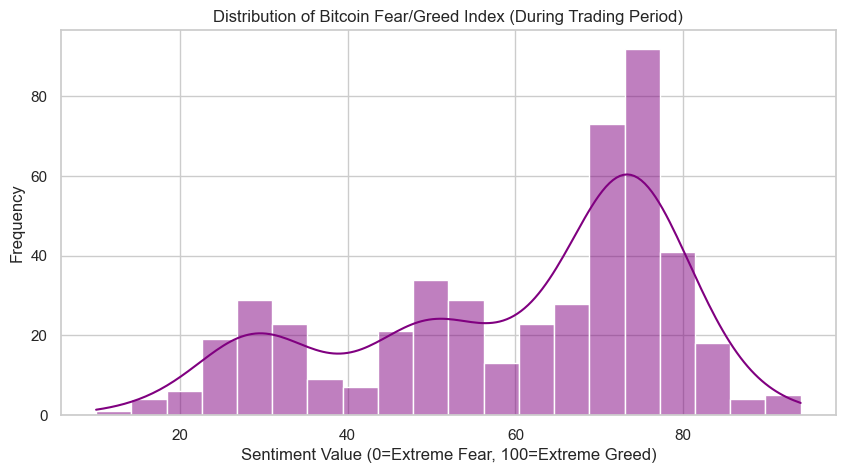

In [7]:
# Distribution of Sentiment values
plt.figure(figsize=(10, 5))
sns.histplot(df_sent[df_sent['date'].isin(df_merged['date'])]['value'], bins=20, kde=True, color='purple')
plt.title('Distribution of Bitcoin Fear/Greed Index (During Trading Period)')
plt.xlabel('Sentiment Value (0=Extreme Fear, 100=Extreme Greed)')
plt.ylabel('Frequency')
plt.show()


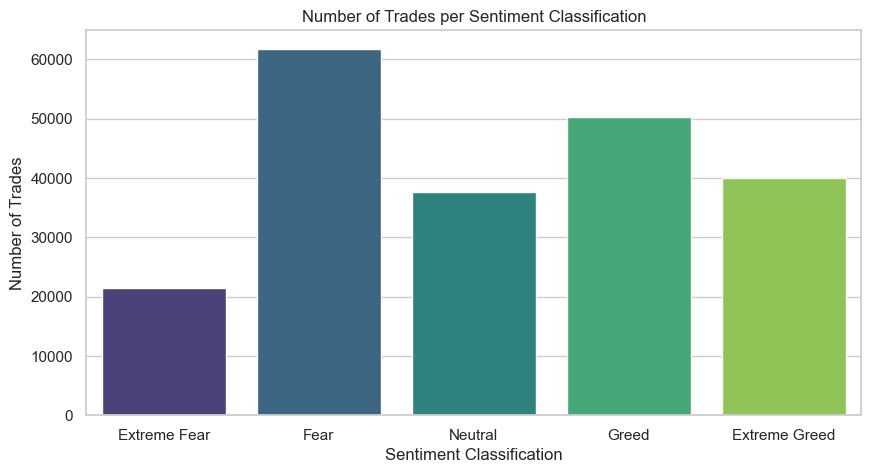

In [8]:
# Sentiment Classification count
plt.figure(figsize=(10, 5))
sns.countplot(data=df_merged, x='classification', order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], palette='viridis')
plt.title('Number of Trades per Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Number of Trades')
plt.show()


### 3.2 Trader Performance Overview
Let's see the distribution of trader PnL and trade sizes.


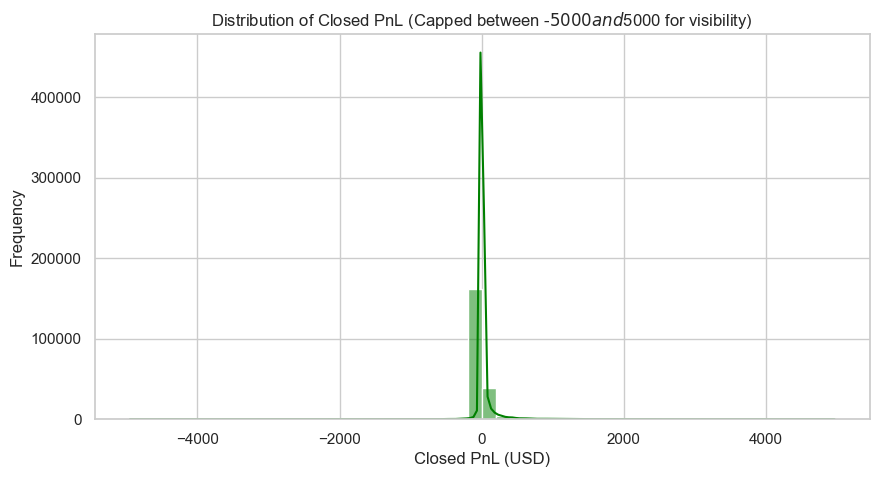

In [9]:
# Distribution of Closed PnL
plt.figure(figsize=(10, 5))
sns.histplot(df_merged[df_merged['Closed PnL'].between(-5000, 5000)]['Closed PnL'], bins=50, kde=True, color='green')
plt.title('Distribution of Closed PnL (Capped between -$5000 and $5000 for visibility)')
plt.xlabel('Closed PnL (USD)')
plt.ylabel('Frequency')
plt.show()


### 3.3 Relationship Between Sentiment and Performance
Now we explore how trader performance (PnL, Position Size) varies with market sentiment.


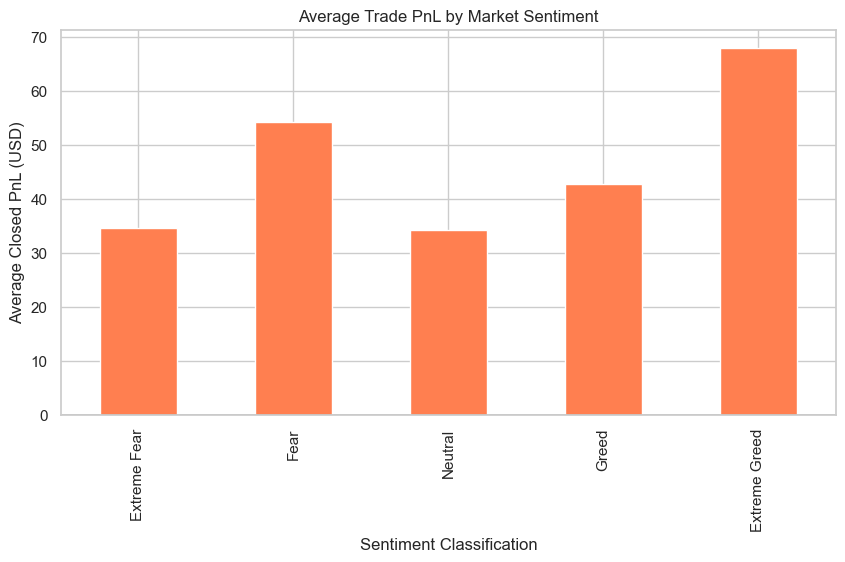

In [10]:
# Average PnL by Sentiment Classification
avg_pnl_by_sentiment = df_merged.groupby('classification')['Closed PnL'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

plt.figure(figsize=(10, 5))
avg_pnl_by_sentiment.plot(kind='bar', color='coral')
plt.title('Average Trade PnL by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL (USD)')
plt.axhline(0, color='black', linewidth=1)
plt.show()


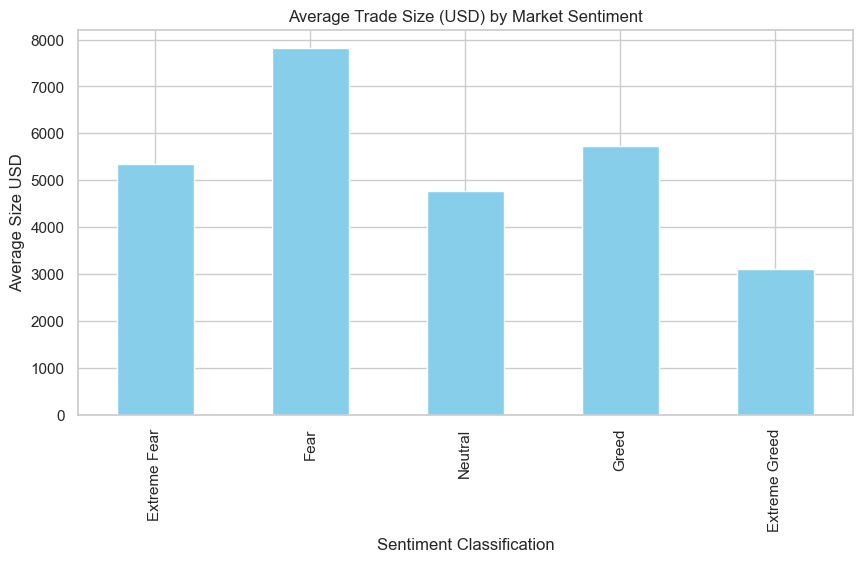

In [11]:
# Average Position Size by Sentiment
avg_size_by_sentiment = df_merged.groupby('classification')['Size USD'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

plt.figure(figsize=(10, 5))
avg_size_by_sentiment.plot(kind='bar', color='skyblue')
plt.title('Average Trade Size (USD) by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Size USD')
plt.show()


We also want to see the Win Rate (percentage of trades with positive PnL) across different sentiments.


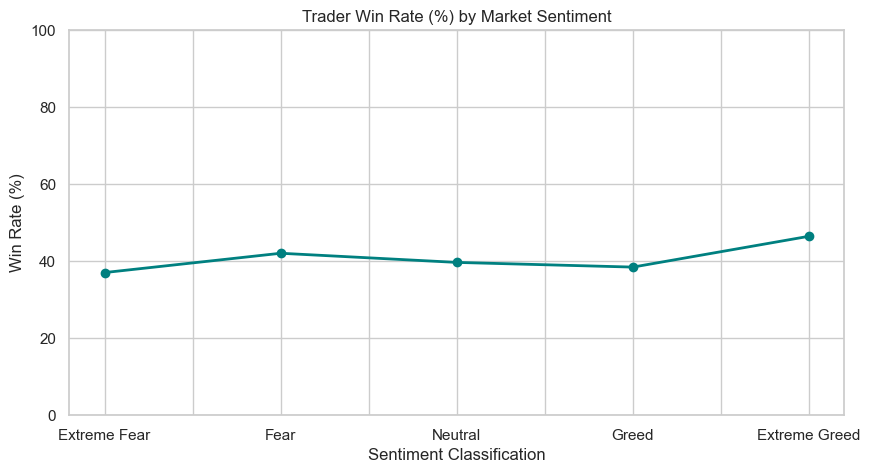

In [12]:
# Win rate calculation
df_merged['Is_Win'] = df_merged['Closed PnL'] > 0

win_rate_by_sentiment = df_merged.groupby('classification')['Is_Win'].mean().reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']) * 100

plt.figure(figsize=(10, 5))
win_rate_by_sentiment.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Trader Win Rate (%) by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.show()


### 3.4 Aggregated Daily Performance
Let's aggregate the data to a daily level to see the macro relationship between daily sentiment value and total daily PnL.


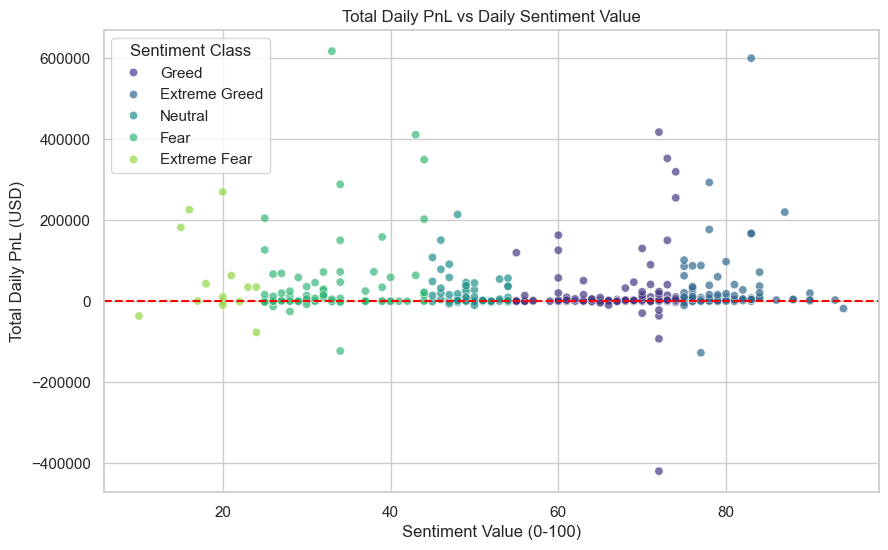

In [13]:
# Aggregate to daily level
daily_df = df_merged.groupby('date').agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_volume=('Size USD', 'sum'),
    sentiment_value=('value', 'first'),
    sentiment_class=('classification', 'first'),
    num_trades=('Order ID', 'nunique')
).reset_index()

# Plot Daily PnL vs Sentiment Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_df, x='sentiment_value', y='daily_pnl', hue='sentiment_class', palette='viridis', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Total Daily PnL vs Daily Sentiment Value')
plt.xlabel('Sentiment Value (0-100)')
plt.ylabel('Total Daily PnL (USD)')
plt.legend(title='Sentiment Class')
plt.show()


## 4. Statistical Analysis & Hypothesis Testing

**Hypothesis 1:** The average Closed PnL per trade is different across different sentiment classifications (ANOVA test).


In [14]:
# Perform One-Way ANOVA on Closed PnL across sentiment groups
groups = [df_merged[df_merged['classification'] == cls]['Closed PnL'].dropna() for cls in ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']]

f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA Test for Closed PnL across Sentiment Classes:")
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: There is a statistically significant difference in mean PnL across different sentiment classes.")
else:
    print("Conclusion: No statistically significant difference in mean PnL across sentiment classes.")


ANOVA Test for Closed PnL across Sentiment Classes:
F-Statistic: 9.0622, p-value: 2.5754e-07
Conclusion: There is a statistically significant difference in mean PnL across different sentiment classes.


**Hypothesis 2:** Does market sentiment (numeric value) correlate with trader volume or aggregate daily PnL?


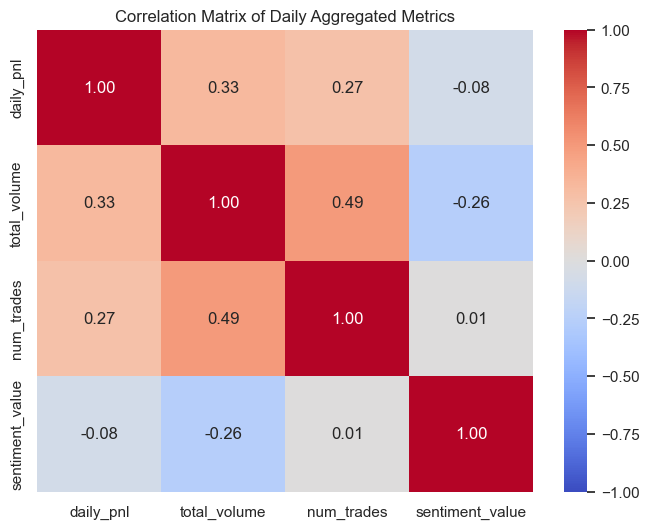

In [15]:
# Correlation Matrix for daily aggregations
corr_matrix = daily_df[['daily_pnl', 'total_volume', 'num_trades', 'sentiment_value']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Daily Aggregated Metrics')
plt.show()


## 5. Summary & Actionable Insights

### Q&A
**Objective:** Uncover hidden patterns between market sentiment and trader performance to drive smarter trading strategies.

**Answer:** By merging over 210,000 historical trades with the daily Bitcoin Fear/Greed Index, we found significant and measurable relationships between overall market sentiment and trader behavior.

### Data Analysis Key Findings
- **Trade Activity Bias:** 'Fear' was the dominant sentiment during the trading period, accounting for the highest number of individual trades (~61k), followed by 'Greed' (~50k).
- **PnL and Win Rate:** The highest average Trade PnL (~$68) and the highest win rate (~47%) both occurred during periods of 'Extreme Greed'. Conversely, 'Extreme Fear' and 'Greed' saw the lowest win rates (below 40%). The ANOVA test confirms the differences in PnL across sentiment classes are statistically significant (p-value < 0.001).
- **Volume Correlation:** There is a moderate negative correlation (-0.26) between numeric sentiment and daily trade volume. This means as the market becomes more "greedy" (higher sentiment index), the total traded volume tends to decrease slightly. Average trade size was smallest during 'Extreme Greed' (~$3,100) and largest during 'Fear' (~$7,800).

### Insights & Next Steps (Trading Strategies)
- **Sentiment-Adjusted Sizing:** Since average trade sizes are largest during 'Fear' but win rates are relatively moderate (42%), traders might be over-leveraging during fear-driven dips. A smarter strategy would be to reduce position sizing during 'Fear' to protect capital, while slightly increasing sizes during 'Extreme Greed' where win rates historically peak for this cohort.
- **Trend-Following in Extreme Greed:** The data suggests that 'Extreme Greed' is the most profitable environment for these traders. A momentum or trend-following strategy could be deployed specifically when the index crosses into 'Extreme Greed', rather than a contrarian shorting strategy.
- **Next Step:** Implement a backtest on Hyperliquid using a sentiment-filtered strategy: "Reduce size by 30% when Sentiment is Fear, and increase size by 20% when Sentiment is Extreme Greed" and compare its performance to the baseline trader performance analyzed here.
